# PPC2: Aplicação do método de Bairstow na obtenção de raízes de polinômios

Neste notebook, foi implementado o método de Bairstow para calcular numericamente as raízes de polinômios. A ideia é testar o método em casos conhecidos, analisar sua convergência e depois aplicá-lo ao polinômio característico obtido na APC2.

# Aluno: Felipe Tavares Loureiro  
# Disciplina: ENM0227 - Cálculo Numérico Aplicado  
# Semestre: 2026.1


## Objetivos

1. Implementar o método de Bairstow para polinômios de grau arbitrário.
2. Testar a implementação em um polinômio de 7ª ordem com raízes conhecidas.
3. Analisar como os valores iniciais $r_0$ e $s_0$ afetam a convergência do método.
4. Resolver o polinômio característico obtido na APC2.
5. Interpretar o significado físico das raízes encontradas.
6. Fazer uma varredura dos chutes iniciais para visualizar regiões de convergência.
7. Construir o fractal de Bairstow associado ao problema.

#Questão 1
Implemente o método de Bairstow para determinar as raízes de um polinômio de
grau arbitrário, incluindo o tratamento de raízes complexas conjugadas;

In [89]:
import math                              # Operações matemáticas
import matplotlib.pyplot as plt          # Construção de gráficos
from matplotlib.colors import ListedColormap, BoundaryNorm   # Coloração das bacias de convergência

In [90]:
# x^2 - r*x - s
def bairstow(coeficientes, s0=1, r0=1, tol=0.00001, max_iter=1000):   # Função principal do método de Bairstow
    def normalizar_lista(lista):
        if len(lista) == 1 and isinstance(lista[0], (list, tuple)):   # Corrige caso os coeficientes venham aninhados
            return list(lista[0])
        return list(lista)                                             # Garante que a entrada seja uma lista comum

    def limpar_numero(z):
        if isinstance(z, complex):
            if abs(z.imag) < 1e-10:                                    # Remove parte imaginária residual numérica
                return z.real
            return z
        return z

    def resolver_quadratica(a, b, c):
        discriminante = b * b - 4 * a * c                              # Calcula o discriminante da equação de 2º grau
        raiz_discriminante = discriminante ** 0.5                      # Extrai a raiz do discriminante
        return [
            (-b + raiz_discriminante) / (2 * a),                       # Primeira raiz
            (-b - raiz_discriminante) / (2 * a)                        # Segunda raiz
        ]

    def bairstow_par(coeficientes_par, r_inicial, s_inicial):
        r = complex(r_inicial, 0)                                      # Inicializa r como complexo
        s = complex(s_inicial, 0)                                      # Inicializa s como complexo
        coeficientes_a = [complex(c, 0) if not isinstance(c, complex) else c for c in coeficientes_par]

        err = tol * 1000                                               # Começa com erro alto para entrar no laço
        iteracao = 0                                                   # Contador de iterações

        while err > tol and iteracao < max_iter:
            coeficientes_b = [
                coeficientes_a[0],                                     # Primeiro termo da recorrência
                coeficientes_a[1] + r * coeficientes_a[0]              # Segundo termo da recorrência
            ]

            for i in range(2, len(coeficientes_a)):
                coeficientes_b.append(
                    coeficientes_a[i]
                    + r * coeficientes_b[i - 1]
                    + s * coeficientes_b[i - 2]                        # Relação recursiva para obter os b_i
                )

            resto_x = coeficientes_b[-2]                               # Coeficiente do termo em x no resto
            resto_constante = coeficientes_b[-1]                       # Termo constante do resto
            err = max(abs(resto_x), abs(resto_constante))              # Erro adotado no critério de parada

            if err <= tol:
                quociente = coeficientes_b[:-2]                        # Quociente após remover o fator quadrático
                discriminante = r * r + 4 * s                          # Discriminante de x^2 - r*x - s
                raiz_discriminante = discriminante ** 0.5
                raiz1 = (r + raiz_discriminante) / 2                   # Primeira raiz do fator quadrático
                raiz2 = (r - raiz_discriminante) / 2                   # Segunda raiz do fator quadrático

                return {
                    "convergiu": True,
                    "r": r,
                    "s": s,
                    "quociente": quociente,
                    "raizes": [raiz1, raiz2],
                    "iteracoes": iteracao + 1,
                    "erro": err
                }

            derivada_r = [0j] * len(coeficientes_a)                    # Vetor auxiliar para derivadas em relação a r
            derivada_s = [0j] * len(coeficientes_a)                    # Vetor auxiliar para derivadas em relação a s

            derivada_r[1] = coeficientes_b[0]                          # Condição inicial da derivada em relação a r

            for i in range(2, len(coeficientes_a)):
                derivada_r[i] = (
                    coeficientes_b[i - 1]
                    + r * derivada_r[i - 1]
                    + s * derivada_r[i - 2]                            # Recorrência da derivada parcial em r
                )
                derivada_s[i] = (
                    coeficientes_b[i - 2]
                    + r * derivada_s[i - 1]
                    + s * derivada_s[i - 2]                            # Recorrência da derivada parcial em s
                )

            a11 = derivada_r[-2]                                       # Elemento da matriz jacobiana
            a12 = derivada_s[-2]                                       # Elemento da matriz jacobiana
            a21 = derivada_r[-1]                                       # Elemento da matriz jacobiana
            a22 = derivada_s[-1]                                       # Elemento da matriz jacobiana

            determinante = a11 * a22 - a12 * a21                       # Determinante do sistema linear

            if abs(determinante) < 1e-14:
                return {
                    "convergiu": False,                                # Falha por singularidade numérica
                    "r": r,
                    "s": s,
                    "quociente": None,
                    "raizes": [],
                    "iteracoes": iteracao + 1,
                    "erro": err
                }

            delta_r = (-resto_x * a22 + resto_constante * a12) / determinante   # Correção de r
            delta_s = (a21 * resto_x - a11 * resto_constante) / determinante    # Correção de s

            r += delta_r                                                # Atualiza r
            s += delta_s                                                # Atualiza s
            iteracao += 1                                               # Avança uma iteração

        return {
            "convergiu": False,                                         # Sai sem convergir dentro do limite
            "r": r,
            "s": s,
            "quociente": None,
            "raizes": [],
            "iteracoes": iteracao,
            "erro": err
        }

    coeficientes = normalizar_lista(coeficientes)                       # Normaliza a entrada
    coeficientes = [complex(c, 0) if not isinstance(c, complex) else c for c in coeficientes]

    while len(coeficientes) > 1 and abs(coeficientes[0]) < 1e-14:
        coeficientes.pop(0)                                             # Remove zeros à esquerda, se houver

    if len(coeficientes) < 2:
        return {
            "convergiu": False,                                         # Caso degenerado, sem polinômio útil
            "raizes": [],
            "iteracoes": 0,
            "erro": None
        }

    if len(coeficientes) == 2:
        raiz = -coeficientes[1] / coeficientes[0]                       # Resolve diretamente equação linear
        return {
            "convergiu": True,
            "raizes": [limpar_numero(raiz)],
            "iteracoes": 0,
            "erro": 0.0
        }

    if len(coeficientes) == 3:
        raizes = resolver_quadratica(coeficientes[0], coeficientes[1], coeficientes[2])  # Resolve diretamente equação quadrática
        return {
            "convergiu": True,
            "raizes": [limpar_numero(z) for z in raizes],
            "iteracoes": 0,
            "erro": 0.0
        }

    coeficientes_atuais = coeficientes[:]                               # Cópia dos coeficientes para deflação sucessiva
    lista_raizes = []                                                   # Armazena as raízes encontradas
    lista_fatores = []                                                  # Armazena os fatores quadráticos encontrados
    iteracoes_totais = 0                                                # Soma total de iterações
    ultimo_erro = None                                                  # Guarda o último erro calculado

    r_atual = r0                                                        # Chute inicial de r
    s_atual = s0                                                        # Chute inicial de s

    while len(coeficientes_atuais) > 3:
        resultado_parcial = bairstow_par(coeficientes_atuais, r_atual, s_atual)  # Extrai um fator quadrático por vez
        iteracoes_totais += resultado_parcial["iteracoes"]
        ultimo_erro = resultado_parcial["erro"]

        if not resultado_parcial["convergiu"]:
            return {
                "convergiu": False,
                "raizes": [limpar_numero(z) for z in lista_raizes],
                "fatores_quadraticos": lista_fatores,
                "iteracoes": iteracoes_totais,
                "erro": ultimo_erro
            }

        lista_raizes.extend(resultado_parcial["raizes"])                # Adiciona as raízes do fator encontrado
        lista_fatores.append(
            (
                limpar_numero(resultado_parcial["r"]),
                limpar_numero(resultado_parcial["s"])
            )
        )
        coeficientes_atuais = resultado_parcial["quociente"]            # Atualiza o polinômio por deflação

        r_atual = limpar_numero(resultado_parcial["r"])                 # Usa o último r como novo chute
        s_atual = limpar_numero(resultado_parcial["s"])                 # Usa o último s como novo chute

    if len(coeficientes_atuais) == 3:
        lista_raizes.extend(
            resolver_quadratica(
                coeficientes_atuais[0],
                coeficientes_atuais[1],
                coeficientes_atuais[2]
            )
        )                                                               # Resolve o último fator quadrático
    elif len(coeficientes_atuais) == 2:
        lista_raizes.append(-coeficientes_atuais[1] / coeficientes_atuais[0])   # Resolve o último fator linear

    return {
        "convergiu": True,
        "raizes": [limpar_numero(z) for z in lista_raizes],
        "fatores_quadraticos": lista_fatores,
        "iteracoes": iteracoes_totais,
        "erro": ultimo_erro
    }

# Questão 2: Valide o programa construindo um polinômio de sétima ordem com raízes previamente conhecidas (por exemplo, obtido a partir da multiplicação de seus monômios) e verificando se o método é capaz de recuperar essas raízes dentro de uma tolerância numérica adequada;

Foi escolhido um polinômio de sétima ordem com raízes reais conhecidas, dado por

$$
P(x) = (x-7)(x-6)(x-5)(x-4)(x-3)(x-2)(x-1)
$$

Ao expandir a expressão, obtém-se

$$
P(x) = x^7 - 28x^6 + 322x^5 - 1960x^4 + 6769x^3 - 13132x^2 + 13068x - 5040
$$

A escolha desse polinômio é conveniente porque suas raízes exatas são conhecidas previamente,
isto é,

$$
x = 1,\;2,\;3,\;4,\;5,\;6,\;7
$$

Assim, é possível comparar diretamente as raízes obtidas numericamente com os valores exatos,
verificando se o algoritmo foi implementado corretamente.

In [91]:
# Polinômio de validação:
# P(x) = (x-7)(x-6)(x-5)(x-4)(x-3)(x-2)(x-1)
#      = x^7 - 28x^6 + 322x^5 - 1960x^4 + 6769x^3 - 13132x^2 + 13068x - 5040

coeficientes_teste = [1, -28, 322, -1960, 6769, -13132, 13068, -5040]   # Coeficientes do polinômio expandido

resultado = bairstow(coeficientes_teste, r0=1, s0=-1, tol=1e-8, max_iter=200)   # Aplica o método de Bairstow

print("Convergiu:", resultado["convergiu"])                         # Informa se o método convergiu
print("Número total de iterações:", resultado["iteracoes"])         # Mostra o total de iterações realizadas
print("Erro final:", resultado["erro"])                             # Mostra o erro final obtido
print()

raizes_encontradas = resultado["raizes"]                            # Armazena as raízes calculadas

# Ordena as raízes pelo valor real para facilitar a comparação com as raízes exatas
raizes_encontradas = sorted(
    raizes_encontradas,
    key=lambda z: (round(z.real, 10), round(z.imag, 10))
)

print("Raízes encontradas pelo método de Bairstow:")
for i, raiz in enumerate(raizes_encontradas, start=1):
    print(f"Raiz {i}: {raiz}")                                      # Exibe cada raiz encontrada

print()
print("Raízes exatas esperadas:")
raizes_exatas = [1, 2, 3, 4, 5, 6, 7]                               # Raízes conhecidas do polinômio de validação

for i in range(len(raizes_exatas)):
    print(
        f"Raíz exata esperada {i+1}: {raizes_exatas[i]}   "
        f"Erro da raiz encontrada: {abs(raizes_exatas[i] - raizes_encontradas[i])}"
    )                                                               # Compara cada raiz exata com a correspondente encontrada

Convergiu: True
Número total de iterações: 24
Erro final: 6.59383658785373e-12

Raízes encontradas pelo método de Bairstow:
Raiz 1: 1.0000000000000497
Raiz 2: 1.999999999999961
Raiz 3: 2.9999999999992344
Raiz 4: 3.9999999999995044
Raiz 5: 5.000000000002277
Raiz 6: 5.999999999999902
Raiz 7: 6.999999999999071

Raízes exatas esperadas:
Raíz exata esperada 1: 1   Erro da raiz encontrada: 4.973799150320701e-14
Raíz exata esperada 2: 2   Erro da raiz encontrada: 3.907985046680551e-14
Raíz exata esperada 3: 3   Erro da raiz encontrada: 7.65609797781508e-13
Raíz exata esperada 4: 4   Erro da raiz encontrada: 4.956035581926699e-13
Raíz exata esperada 5: 5   Erro da raiz encontrada: 2.277289468111121e-12
Raíz exata esperada 6: 6   Erro da raiz encontrada: 9.769962616701378e-14
Raíz exata esperada 7: 7   Erro da raiz encontrada: 9.29034627006331e-13


A execução do método para o polinômio de validação apresentou convergência, com 24 iterações e erro final da ordem de $10^{-12}$. Além disso, as raízes obtidas numericamente ficaram extremamente próximas das raízes exatas esperadas, que eram $1, 2, 3, 4, 5, 6$ e $7$.

Os erros individuais encontrados foram todos muito pequenos, variando aproximadamente entre $10^{-14}$ e $10^{-12}$. Isso mostra que o programa conseguiu recuperar corretamente as raízes do polinômio dentro de uma tolerância numérica bastante boa.

As pequenas diferenças observadas entre os valores exatos e os valores calculados são esperadas, pois o método de Bairstow é iterativo e os cálculos são feitos com aritmética de ponto flutuante. Mesmo assim, os resultados foram suficientemente precisos para validar a implementação.

Assim, pode-se concluir que o algoritmo foi implementado corretamente, já que foi capaz de encontrar com boa precisão as raízes de um polinômio cujos valores exatos já eram conhecidos.

#Questão 3 - Analise a convergência do método para diferentes escolhas iniciais dos parâmetros $ r0 $ e $ s0 $, discutindo sua influência na estabilidade e na velocidade de convergência;

In [92]:
# Esta função realiza uma varredura numérica no plano dos parâmetros iniciais (r0, s0),
# contabilizando convergência, número de iterações e distribuição dos erros finais.

def varredura_numerica(coeficientes, r_min=-10, r_max=10, s_min=-10, s_max=10,
                       step=0.1, tol=1e-8, max_iter=200, histogramas=True):   # Faz a varredura numérica dos valores iniciais

    iteracoes = []                       # Armazena o número de iterações dos casos convergentes
    erros = []                           # Armazena os erros finais dos casos convergentes
    total = 0                            # Conta o número total de pares (r0, s0) testados
    convergencias = 0                    # Conta quantos pares levaram à convergência

    r0 = r_min
    while r0 <= r_max + 1e-12:           # Percorre os valores de r0 dentro do intervalo escolhido
        s0 = s_min
        while s0 <= s_max + 1e-12:       # Percorre os valores de s0 dentro do intervalo escolhido
            resultado = bairstow(coeficientes, r0=r0, s0=s0, tol=tol, max_iter=max_iter)   # Aplica o método

            total += 1                   # Atualiza o total de testes realizados

            if resultado["convergiu"]:
                convergencias += 1       # Conta mais um caso convergente
                iteracoes.append(resultado["iteracoes"])   # Guarda o número de iterações

                if resultado["erro"] is not None and resultado["erro"] > 0:
                    erros.append(resultado["erro"])        # Guarda o erro final, se válido

            s0 += step                   # Avança para o próximo valor de s0
        r0 += step                       # Avança para o próximo valor de r0

    print("Total de pares testados:", total)                              # Mostra quantos pares foram analisados
    print("Convergências:", convergencias)                                # Mostra quantos casos convergiram
    print("Taxa de convergência: {:.2f}%".format(100 * convergencias / total))   # Calcula a taxa de convergência

    if len(iteracoes) > 0:
        print("Iterações mínimas:", min(iteracoes))                       # Menor número de iterações observado
        print("Iterações médias: {:.2f}".format(sum(iteracoes) / len(iteracoes)))   # Média de iterações
        print("Iterações máximas:", max(iteracoes))                       # Maior número de iterações observado

    if histogramas and len(iteracoes) > 0:
        plt.figure(figsize=(8,5))                                         # Cria a figura do histograma das iterações
        plt.hist(iteracoes, bins=30)                                      # Monta o histograma do número de iterações
        plt.xlabel("Número de iterações")
        plt.ylabel("Frequência")
        plt.title("Histograma do número de iterações")
        plt.grid(True)
        plt.show()

    if histogramas and len(erros) > 0:
        erros_log = [math.log10(e) for e in erros]                        # Aplica log10 aos erros para facilitar a visualização

        plt.figure(figsize=(8,5))                                         # Cria a figura do histograma dos erros
        plt.hist(erros_log, bins=30)                                      # Monta o histograma de log10(erro final)
        plt.xlabel("log10(erro final)")
        plt.ylabel("Frequência")
        plt.title("Histograma do erro final")
        plt.grid(True)
        plt.show()

Total de pares testados: 10201
Convergências: 10201
Taxa de convergência: 100.00%
Iterações mínimas: 10
Iterações médias: 129.42
Iterações máximas: 3413


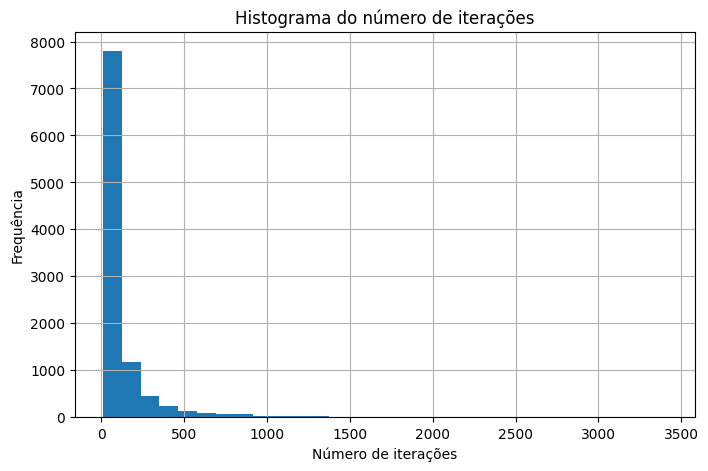

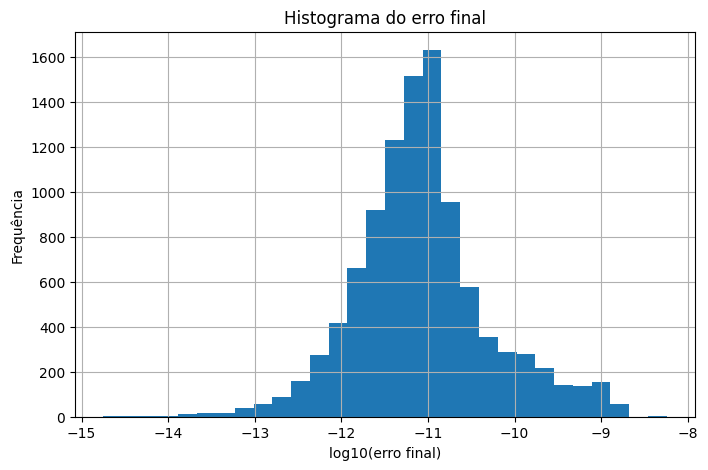

In [93]:
coeficientes_teste = [1, -28, 322, -1960, 6769, -13132, 13068, -5040]

varredura_numerica(
    coeficientes_teste,
    r_min=-100, r_max=100,
    s_min=-100, s_max=100,
    step=2,
    tol=1e-8,
    max_iter=10000
)

Os histogramas mostram que a escolha de $r_0$ e $s_0$ influencia bastante a velocidade de convergência do método. A maior parte dos casos converge com poucas iterações, mas existe uma cauda longa à direita, indicando que algumas escolhas iniciais fazem o método demorar muito mais.

Já os erros finais ficaram concentrados em torno de valores bem pequenos, principalmente perto de $10^{-11}$. Então, mesmo quando o método demora mais para convergir, ele ainda tende a chegar a uma boa precisão final.

Assim, para esse polinômio de grau 7, os parâmetros iniciais afetam mais o número de iterações do que a qualidade final da solução.

Total de pares testados: 251001
Convergências: 251001
Taxa de convergência: 100.00%
Iterações mínimas: 5
Iterações médias: 18.25
Iterações máximas: 30


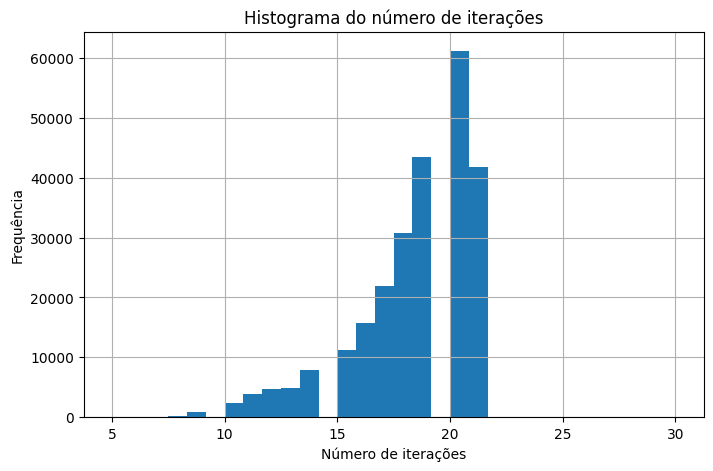

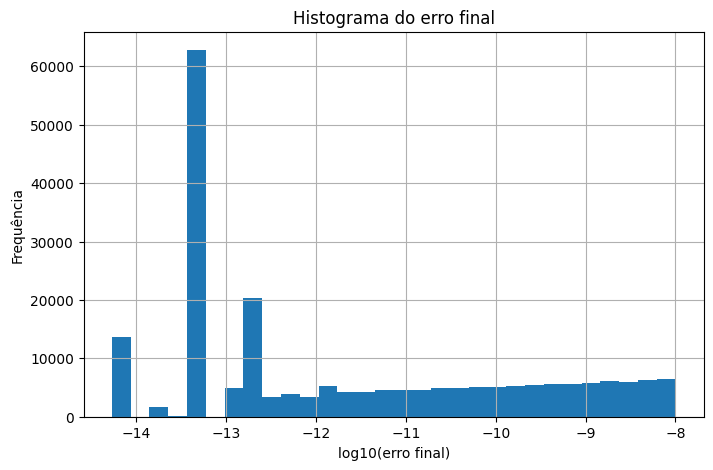

In [94]:
coeficientes_apc2 = [15, 10.5, 330.5, 55,500]

varredura_numerica(
    coeficientes_apc2,
    r_min=-500, r_max=500,
    s_min=-500, s_max=500,
    step=2,
    tol=1e-8,
    max_iter=1000
)

No caso do polinômio do trabalho, a influência de $r_0$ e $s_0$ sobre o número de iterações foi bem menor do que no polinômio de grau 7. O histograma mostra uma concentração forte entre aproximadamente 15 e 21 iterações, indicando um comportamento mais regular e mais estável do método para diferentes escolhas iniciais.

Já os erros finais continuam pequenos, embora distribuídos em faixas diferentes. Isso mostra que, mesmo com variação nos valores iniciais, o método ainda converge com boa precisão, sem perda relevante de qualidade nos resultados.

Assim, para esse polinômio, os parâmetros iniciais ainda influenciam a convergência, mas de forma bem mais controlada, o que sugere que seus coeficientes são numericamente mais bem comportados.


Comparando os dois casos, o polinômio de grau 7 se mostrou bem mais sensível às escolhas iniciais de $r_0$ e $s_0$. Isso aparece no histograma das iterações, que tem uma cauda longa à direita, com vários casos exigindo muitas iterações. Na prática, foi necessário adotar um valor de `max_iter` bem alto para garantir convergência em todos os testes.

Já no polinômio do trabalho, o comportamento foi mais regular. O número de iterações ficou concentrado em uma faixa bem menor, o que indica menor sensibilidade aos valores iniciais e uma convergência mais estável. Os erros finais também permaneceram pequenos nos dois casos, mas, no polinômio do trabalho, isso foi obtido de forma mais uniforme.

Assim, embora ambos os polinômios tenham apresentado boa precisão final, o polinômio do trabalho foi numericamente mais bem comportado, enquanto o polinômio de grau 7 exigiu um esforço computacional bem maior para cobrir todos os casos.

#Questão 4 - Utilize o programa desenvolvido para resolver o polinômio característico obtido na Atividade para Casa (APC2), determinando os autovalores do sistema dinâmico;

In [95]:
coeficientes_apc2 = [15, 10.5, 330.5, 55,500]

resultado_apc2 = bairstow(coeficientes_apc2, r0=1, s0=-1, tol=1e-8, max_iter=200)

print("Convergiu:", resultado_apc2["convergiu"])
print("Número total de iterações:", resultado_apc2["iteracoes"])
print("Erro final:", resultado_apc2["erro"])
print()

raizes_encontradas = resultado_apc2["raizes"]

print("Raízes encontradas pelo método de Bairstow:")
for i, raiz in enumerate(raizes_encontradas, start=1):
    print(f"raiz {i}: {raiz}")

Convergiu: True
Número total de iterações: 6
Erro final: 5.684341886080802e-14

Raízes encontradas pelo método de Bairstow:
raiz 1: (-0.06741832750636934+1.2791261918427799j)
raiz 2: (-0.0674183275063695-1.2791261918427799j)
raiz 3: (-0.28258167249363025+4.498507213641896j)
raiz 4: (-0.28258167249363086-4.498507213641896j)


Aplicando o método de Bairstow ao polinômio característico

$$
P(\lambda)=15\lambda^4+10.5\lambda^3+330.5\lambda^2+55\lambda+500
$$

foram obtidas as raízes

$$
\lambda_{1,2}\approx -0.28258 \pm 4.49851 j
$$

$$
\lambda_{3,4}\approx -0.06742 \pm 1.27913 j
$$


# Questão 5. Interprete os resultados obtidos à luz do comportamento físico do sistema (estabilidade,amortecimento, frequência de oscilação);

$$
\lambda_{1,2}\approx -0.28258 \pm 4.49851i
$$

$$
\lambda_{3,4}\approx -0.06742 \pm 1.27913i
$$

Como todas as raízes possuem parte real negativa, conclui-se que o sistema é estável. Isso significa que, após uma perturbação inicial, a resposta livre decai com o tempo, em vez de crescer.

Como as raízes são complexas, a resposta não é apenas exponencial decrescente, mas oscilatória amortecida. De modo geral, quando uma raiz tem a forma

$$
\lambda = -\sigma \pm i\omega_d
$$

a resposta associada a esse par pode ser escrita na forma

$$
x(t)=e^{-\sigma t}\left(C_1\cos(\omega_d t)+C_2\sin(\omega_d t)\right)
$$

Nessa expressão, a parte real da raiz, isto é, $-\sigma$, controla a velocidade de decaimento da amplitude, enquanto a parte imaginária, $\omega_d$, determina a frequência angular da oscilação.

Portanto, para obter a frequência de vibração de cada modo, basta olhar para a parte imaginária da raiz. No presente caso, tem-se:

para o primeiro par,
$$
\omega_{d1}\approx 4.49851 \text{ rad/s}
$$

para o segundo par,
$$
\omega_{d2}\approx 1.27913 \text{ rad/s}
$$

Se for desejado expressar essas frequências em hertz, basta dividir por $2\pi$:

$$
f=\frac{\omega_d}{2\pi}
$$

Assim,

$$
f_1=\frac{4.49851}{2\pi}\approx 0.716 \text{ Hz}
$$

$$
f_2=\frac{1.27913}{2\pi}\approx 0.204 \text{ Hz}
$$

Isso mostra que o sistema possui dois modos de vibração: um modo mais rápido e outro mais lento.

Também é possível calcular a frequência natural não amortecida de cada modo usando

$$
\omega_n=\sqrt{\sigma^2+\omega_d^2}
$$

Para o primeiro modo,

$$
\omega_{n1}=\sqrt{(0.28258)^2+(4.49851)^2}\approx 4.5074 \text{ rad/s}
$$

Para o segundo modo,

$$
\omega_{n2}=\sqrt{(0.06742)^2+(1.27913)^2}\approx 1.2809 \text{ rad/s}
$$

A razão de amortecimento pode ser estimada por

$$
\zeta=\frac{\sigma}{\omega_n}
$$

Logo,

$$
\zeta_1\approx \frac{0.28258}{4.5074}\approx 0.0627
$$

$$
\zeta_2\approx \frac{0.06742}{1.2809}\approx 0.0526
$$

Como esses valores são pequenos, conclui-se que os dois modos são subamortecidos. Em termos físicos, isso significa que o sistema oscila várias vezes antes de parar.

Além disso, comparando as partes reais das raízes, observa-se que o primeiro modo decai mais rapidamente, pois possui parte real mais negativa. Já o segundo modo decai mais lentamente e, por isso, tende a permanecer por mais tempo na resposta temporal.

Em resumo, os autovalores mostram que o sistema é estável, apresenta resposta oscilatória amortecida e possui dois modos de vibração distintos, ambos com baixo amortecimento.

# Questão 6 - Desenvolva uma rotina adicional que realize uma varredura sistemática dos valores iniciais $r0$ e $s0$ no plano bidimensional, registrando o comportamento de convergência do método;


Foi implementada uma rotina de varredura gráfica no plano dos parâmetros iniciais $(r_0,s_0)$, com o objetivo de analisar como a escolha desses valores influencia a convergência do método de Bairstow. Para cada ponto da malha, registra-se o número de iterações necessário para convergir e a bacia de convergência associada.

In [96]:
def varredura_grafica(coeficientes, r_min=-10, r_max=10, s_min=-10, s_max=10, step=0.1,
                      cmap_iter='coolwarm', cmap_bacias='tab10', tol=1e-5, max_iter=100):   # Faz a varredura gráfica no plano (r0,s0)

    def chave_bacia(resultado):
        if not resultado["convergiu"]:
            return 0                                              # Código 0 representa ausência de convergência

        fator = resultado["fatores_quadraticos"][0]               # Seleciona o primeiro fator quadrático encontrado
        r = fator[0].real if isinstance(fator[0], complex) else fator[0]   # Extrai r do fator
        s = fator[1].real if isinstance(fator[1], complex) else fator[1]   # Extrai s do fator

        return (round(r, 4), round(s, 4))                         # Arredonda para agrupar fatores numericamente equivalentes

    lista_r = []
    r = r_min
    while r <= r_max + 1e-12:
        lista_r.append(r)                                         # Monta a lista de valores de r0
        r += step

    lista_s = []
    s = s_min
    while s <= s_max + 1e-12:
        lista_s.append(s)                                         # Monta a lista de valores de s0
        s += step

    matriz_iter = []                                              # Matriz com o número de iterações em cada ponto
    matriz_bacias = []                                            # Matriz com os códigos das bacias de convergência

    codigos_bacias = {}                                           # Dicionário que associa cada bacia a um código numérico

    for s0 in lista_s:
        linha_iter = []                                           # Linha da matriz de iterações
        linha_bacias = []                                         # Linha da matriz de bacias

        for r0 in lista_r:
            resultado = bairstow(coeficientes, r0=r0, s0=s0, tol=tol, max_iter=max_iter)   # Aplica o método em cada par (r0,s0)

            if resultado["convergiu"]:
                linha_iter.append(resultado["iteracoes"])         # Guarda o número de iterações se convergiu
            else:
                linha_iter.append(max_iter)                       # Usa max_iter como valor de referência para não convergência

            chave = chave_bacia(resultado)                        # Identifica a bacia associada ao resultado

            if chave == 0:
                linha_bacias.append(0)                            # Marca explicitamente os pontos que não convergiram
            else:
                if chave not in codigos_bacias:
                    codigos_bacias[chave] = len(codigos_bacias) + 1   # Cria um novo código para cada nova bacia encontrada
                linha_bacias.append(codigos_bacias[chave])        # Registra o código da bacia correspondente

        matriz_iter.append(linha_iter)                            # Adiciona a linha à matriz de iterações
        matriz_bacias.append(linha_bacias)                        # Adiciona a linha à matriz de bacias

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))               # Cria duas figuras lado a lado

    img1 = axs[0].imshow(
        matriz_iter,
        origin='lower',                                           # Faz o gráfico começar no canto inferior esquerdo
        extent=[r_min, r_max, s_min, s_max],                      # Ajusta a escala dos eixos
        aspect='auto',
        cmap=cmap_iter                                            # Define o mapa de cores das iterações
    )
    axs[0].set_title('Número de iterações')
    axs[0].set_xlabel('r')
    axs[0].set_ylabel('s')
    plt.colorbar(img1, ax=axs[0], label='Iterações')              # Adiciona a barra de cores do gráfico de iterações

    n_bacias = len(codigos_bacias)                                # Conta o número de bacias encontradas
    cmap_discreto = ListedColormap(plt.get_cmap(cmap_bacias)(range(n_bacias + 1)))   # Cria um mapa de cores discreto
    norm = BoundaryNorm(range(n_bacias + 2), cmap_discreto.N)    # Define fronteiras entre os códigos inteiros das bacias

    img2 = axs[1].imshow(
        matriz_bacias,
        origin='lower',                                           # Mantém a mesma orientação do gráfico anterior
        extent=[r_min, r_max, s_min, s_max],                      # Ajusta a escala dos eixos
        aspect='auto',
        cmap=cmap_discreto,                                       # Usa coloração discreta para separar as bacias
        norm=norm
    )
    axs[1].set_title('Bacias de atração')
    axs[1].set_xlabel('r')
    axs[1].set_ylabel('s')
    plt.colorbar(img2, ax=axs[1], label='Bacia')                  # Adiciona a barra de cores do gráfico das bacias

    plt.tight_layout()                                            # Ajusta automaticamente o espaçamento entre os gráficos
    plt.show()                                                    # Exibe os gráficos

    print("0 -> não convergiu")                                   # Explica o significado do código 0
    for chave, codigo in codigos_bacias.items():
        print(f"{codigo} -> x² - ({chave[0]})x - ({chave[1]})")   # Mostra a correspondência entre código e fator quadrático

# Questão 7 - A partir dessa varredura, construa o fractal de Bairstow associado ao polinômio em estudo, identificando regiões de convergência e possíveis padrões estruturais no plano (r, s).


A partir da varredura gráfica construída na questão anterior, foram gerados os mapas de número de iterações e das bacias de convergência. Esses resultados permitem interpretar o comportamento do método em função das escolhas iniciais de $r_0$ e $s_0$.

Iniciando a varredura gráfica do polinômio P(λ) = 15λ^4 + 10.5λ^3 + 330.5λ^2 + 55λ + 500
Serão feitas 5 varreduras, com zooms progressivos na fronteira entre as bacias.

[1/5] Executando visão distante da região total...


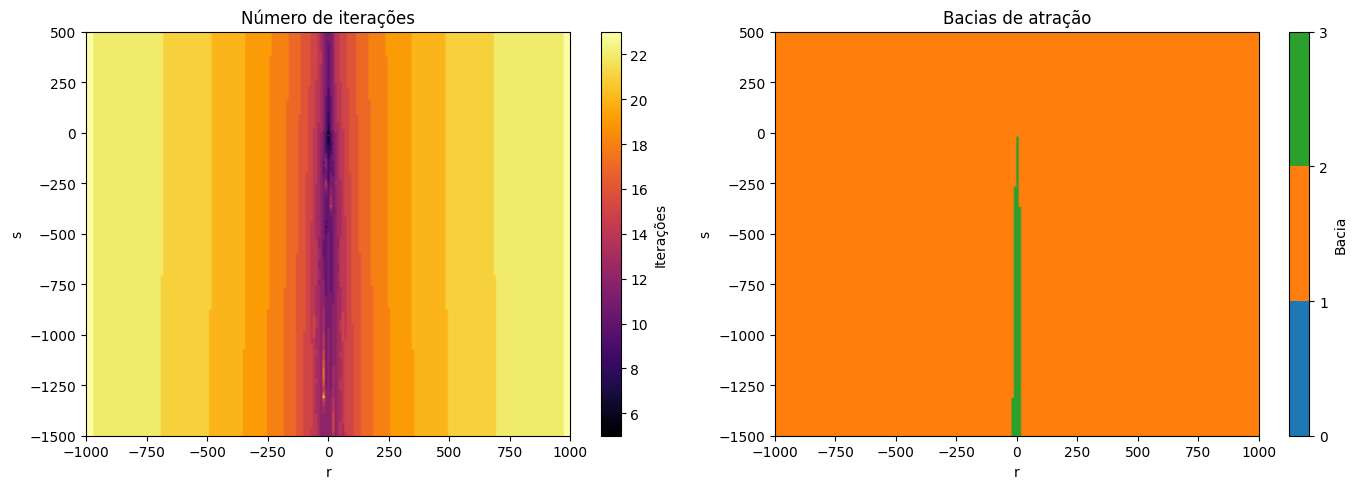

0 -> não convergiu
1 -> x² - (-0.1348)x - (-1.6407)
2 -> x² - (-0.5652)x - (-20.3164)
[1/5] Concluída.
[2/5] Executando visão intermediária para localizar melhor a fronteira...


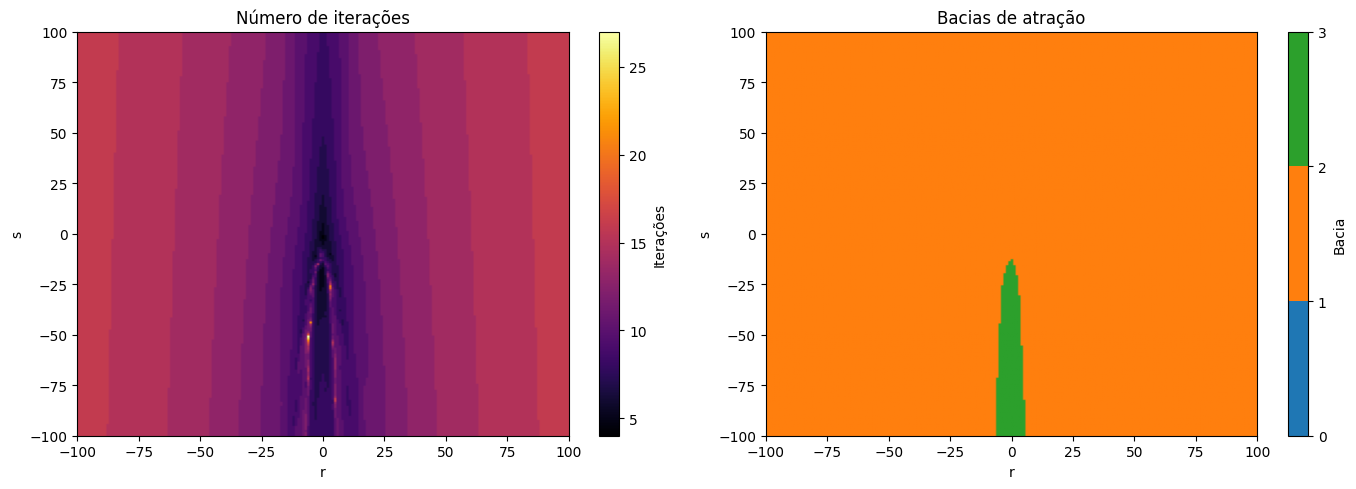

0 -> não convergiu
1 -> x² - (-0.1348)x - (-1.6407)
2 -> x² - (-0.5652)x - (-20.3164)
[2/5] Concluída.
[3/5] Executando primeiro zoom detalhado na região de interesse...


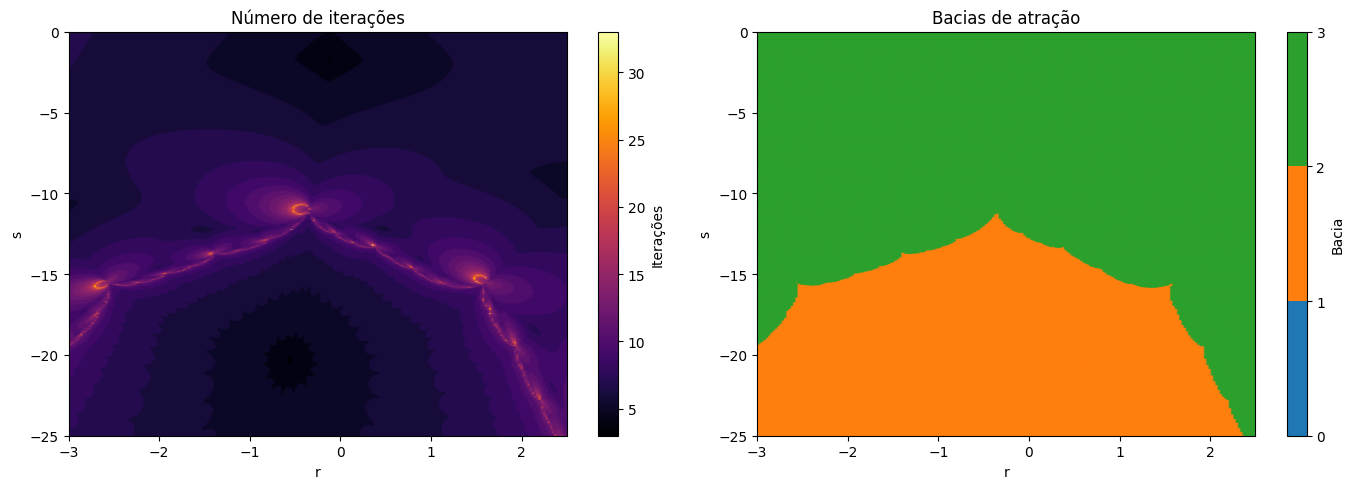

0 -> não convergiu
1 -> x² - (-0.5652)x - (-20.3164)
2 -> x² - (-0.1348)x - (-1.6407)
[3/5] Concluída.
[4/5] Executando segundo zoom, refinando a fronteira observada...


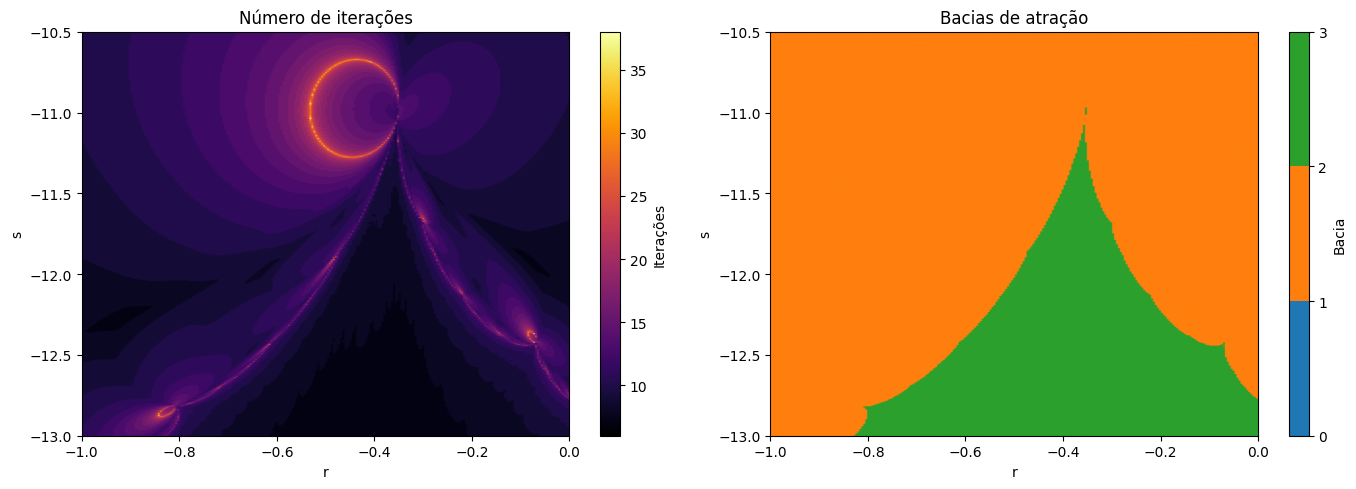

0 -> não convergiu
1 -> x² - (-0.1348)x - (-1.6407)
2 -> x² - (-0.5652)x - (-20.3164)
[4/5] Concluída.
[5/5] Executando zoom final em alta resolução...
Esta etapa é a mais demorada, pois usa uma malha bem mais fina que as anteriores.
Até aqui, as 4 etapas anteriores já foram concluídas; falta apenas esta última.


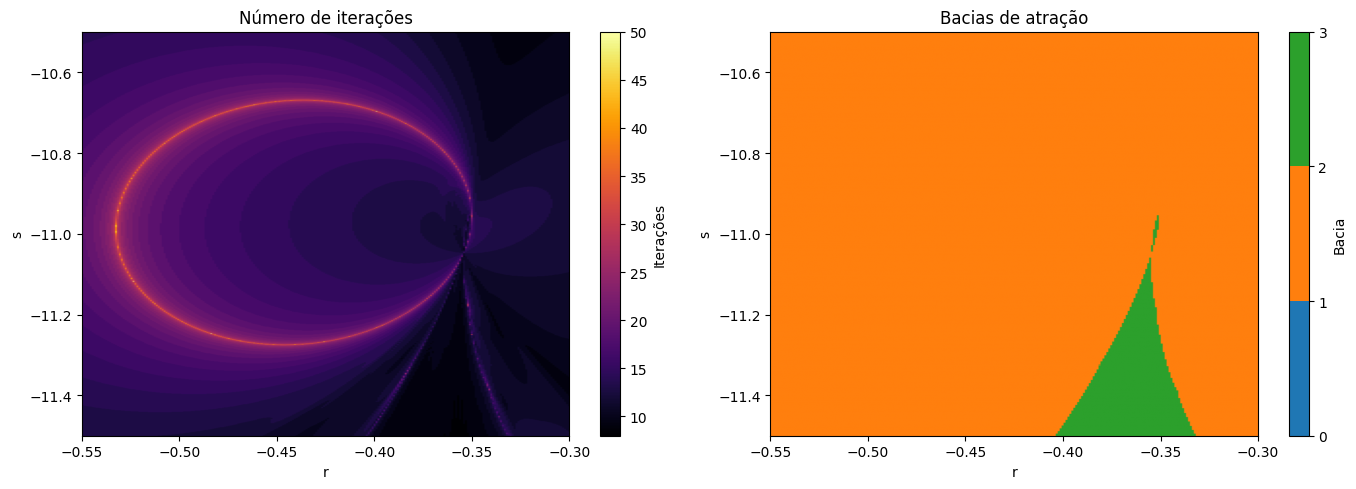

0 -> não convergiu
1 -> x² - (-0.1348)x - (-1.6407)
2 -> x² - (-0.5652)x - (-20.3164)
[5/5] Concluída.
Varredura gráfica finalizada.


In [97]:
coeficientes_apc2 = [15, 10.5, 330.5, 55, 500]   # Coeficientes do polinômio analisado

print("Iniciando a varredura gráfica do polinômio P(λ) = 15λ^4 + 10.5λ^3 + 330.5λ^2 + 55λ + 500")
print("Serão feitas 5 varreduras, com zooms progressivos na fronteira entre as bacias.")
print()

print("[1/5] Executando visão distante da região total...")
varredura_grafica(
    coeficientes_apc2,
    r_min=-1000, r_max=1000,            # Intervalo amplo para r
    s_min=-1500, s_max=500,             # Intervalo amplo para s
    step=10,                            # Passo maior, adequado para uma visão geral
    cmap_iter='inferno'                 # Mapa de cores do gráfico de iterações
)
print("[1/5] Concluída.")
print("=" * 100)

print("[2/5] Executando visão intermediária para localizar melhor a fronteira...")
varredura_grafica(
    coeficientes_apc2,
    r_min=-100, r_max=100,              # Intervalo reduzido para r
    s_min=-100, s_max=100,              # Intervalo reduzido para s
    step=1,                             # Passo menor para aumentar o detalhamento
    cmap_iter='inferno'
)
print("[2/5] Concluída.")
print("=" * 100)

print("[3/5] Executando primeiro zoom detalhado na região de interesse...")
varredura_grafica(
    coeficientes_apc2,
    r_min=-3, r_max=2.5,                # Faixa mais estreita para r
    s_min=-25, s_max=0,                 # Faixa mais estreita para s
    step=0.025,                         # Passo pequeno para melhor resolução
    cmap_iter='inferno'
)
print("[3/5] Concluída.")
print("=" * 100)

print("[4/5] Executando segundo zoom, refinando a fronteira observada...")
varredura_grafica(
    coeficientes_apc2,
    r_min=-1, r_max=0,                  # Janela mais localizada em r
    s_min=-13, s_max=-10.5,             # Janela mais localizada em s
    step=0.004,                         # Passo ainda menor para refinar a visualização
    cmap_iter='inferno'
)
print("[4/5] Concluída.")
print("=" * 100)

print("[5/5] Executando zoom final em alta resolução...")
print("Esta etapa é a mais demorada, pois usa uma malha bem mais fina que as anteriores.")
print("Até aqui, as 4 etapas anteriores já foram concluídas; falta apenas esta última.")
varredura_grafica(
    coeficientes_apc2,
    r_min=-0.55, r_max=-0.3,            # Região muito pequena em r
    s_min=-11.5, s_max=-10.5,           # Região muito pequena em s
    step=0.001,                         # Passo fino para análise detalhada
    cmap_iter='inferno'
)
print("[5/5] Concluída.")
print("Varredura gráfica finalizada.")

A aplicação da varredura gráfica ao polinômio do trabalho mostrou que, nas regiões analisadas, o método sempre convergiu (ausência de azul nos gráficos das bacias). Além disso, foram observadas sempre duas bacias de convergência, correspondentes aos dois fatores quadráticos para os quais o método pode convergir primeiro.

As bacias de atração representam os conjuntos de valores iniciais $(r_0,s_0)$ que levam o método a convergir para um mesmo fator quadrático. Assim, pontos iniciais em uma mesma bacia produzem o mesmo destino final para a iteração, enquanto pontos em bacias diferentes levam a fatores diferentes.

Nos gráficos mais afastados, vê-se que uma das bacias domina quase todo o plano analisado, enquanto a outra aparece como uma região bem mais estreita. Já nos zooms, a fronteira entre essas bacias revela uma estrutura irregular, com aspecto fractal. Isso indica alta sensibilidade às condições iniciais nessa região: pequenas variações em $r_0$ e $s_0$ podem mudar completamente o fator para o qual o método converge.

Os gráficos do número de iterações reforçam essa interpretação. Longe das fronteiras entre bacias, a convergência tende a ocorrer com menos iterações e de forma mais regular. Já perto das fronteiras, o número de iterações aumenta e surgem padrões mais complexos, mostrando que essa é a região numericamente mais delicada do problema.

Portanto, a questão 7 mostra que o método de Bairstow, embora tenha convergido em todos os casos analisados, não responde de forma uniforme aos valores iniciais. A existência de duas bacias de atração e de fronteiras com estrutura fractal evidencia que a escolha de $r_0$ e $s_0$ pode influenciar bastante o caminho da convergência.